# Quantifying the Operational ROI and Engineering Bottlenecks of Internal Developer Platforms (IDP)
### Final Report — Exploratory Data Analysis, Complexity Scoring, Squad Segmentation & Model Comparison

**Research Question:** Can engineering infrastructure telemetry be used to predict software deployment cycle times, isolate systemic technical debt, and mathematically segment developer squads in order to optimize adoption of an Internal Developer Platform (IDP)?

This notebook covers the full scope of the capstone: data cleaning, exploratory data analysis, feature engineering, a baseline and tuned regression models predicting `Deployment_Cycle_Time`, a PCA-based "systemic structural complexity" score, and a K-Means segmentation of engineering squads.

#### Contents
1. [Data Loading & Overview](#1.-Data-Loading-&-Overview)
2. [Data Cleaning](#2.-Data-Cleaning)
3. [Outlier Analysis](#3.-Outlier-Analysis)
4. [Feature Engineering](#4.-Feature-Engineering)
5. [Exploratory Visualizations](#5.-Exploratory-Visualizations)
6. [Baseline Regression Model](#6.-Baseline-Regression-Model)
7. [Principal Component Analysis: Systemic Structural Complexity](#7.-Principal-Component-Analysis:-Systemic-Structural-Complexity)
8. [K-Means Squad Segmentation](#8.-K-Means-Squad-Segmentation)
9. [Model Comparison: Ridge & Random Forest with Grid Search](#9.-Model-Comparison:-Ridge-&-Random-Forest-with-Grid-Search)
10. [Summary of Findings](#10.-Summary-of-Findings)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LassoCV
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

## 1. Data Loading & Overview

**Data source:** No public dataset captures IDP adoption telemetry alongside squad-level deployment cycle times, so this project uses an **engineered/simulated dataset** (`data/idp_deployment_telemetry.csv`, generated by `data/generate_dataset.py`) built to match the schema in the capstone prospectus. The data-generating process encodes realistic, non-trivial relationships (e.g., platform adoption reduces cycle time, architectural complexity increases it) plus deliberately injected missing values, duplicate rows, and outlier "incident" deployments, so this EDA reflects genuine data-cleaning work rather than a toy example.

**Schema:**

| Feature | Type | Description |
|---|---|---|
| `Team_Size` | Discrete | Active contributors on the engineering squad |
| `Offshore_Ratio` | Continuous (0-1) | Share of the team distributed across time zones |
| `Microservice_Deps` | Discrete | Downstream architectural dependencies |
| `Helm_Template_Lines` | Continuous | Size/complexity of infrastructure-as-code manifests |
| `Repo_Code_Churn` | Continuous | Lines of code modified/deleted in the deployment window |
| `IDP_API_Calls` | Continuous | Developer interactions with the platform API per sprint |
| `GitOps_Auto_Sync` | Binary | Whether automated GitOps deployment is enabled |
| `Manual_Kubectl_Count` | Continuous | Direct cluster bypass commands executed by developers |
| `Deployment_Cycle_Time` | Continuous (hours) | **Target.** PR-open to production-ready elapsed time |

In [2]:
df = pd.read_csv('data/idp_deployment_telemetry.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1015, 9)


,Team_Size,Offshore_Ratio,Microservice_Deps,Helm_Template_Lines,Repo_Code_Churn,IDP_API_Calls,GitOps_Auto_Sync,Manual_Kubectl_Count,Deployment_Cycle_Time
0,4,0.803,4,134.0,148.0,26.0,0,14.0,53.25
1,8,0.372,14,799.0,314.0,0.0,0,26.0,94.59
2,6,0.341,10,675.0,348.0,55.0,1,14.0,54.10
3,3,0.387,10,477.0,136.0,35.0,0,20.0,80.96
4,13,0.189,9,492.0,275.0,71.0,1,10.0,43.41


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Team_Size              1015 non-null   int64  
 1   Offshore_Ratio         975 non-null    float64
 2   Microservice_Deps      1015 non-null   int64  
 3   Helm_Template_Lines    964 non-null    float64
 4   Repo_Code_Churn        974 non-null    float64
 5   IDP_API_Calls          984 non-null    float64
 6   GitOps_Auto_Sync       1015 non-null   int64  
 7   Manual_Kubectl_Count   1015 non-null   float64
 8   Deployment_Cycle_Time  1015 non-null   float64
dtypes: float64(6), int64(3)
memory usage: 71.5 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Team_Size,1015.0,8.887685,3.807135,3.000,6.000,9.000,12.000,15.000
Offshore_Ratio,975.0,0.401238,0.192860,0.004,0.249,0.387,0.539,0.927
Microservice_Deps,1015.0,6.390148,4.553809,1.000,2.000,6.000,10.000,22.000
Helm_Template_Lines,964.0,380.237552,270.307549,20.000,147.000,370.000,556.250,1261.000
Repo_Code_Churn,974.0,208.392197,128.088349,5.000,114.250,194.000,298.000,586.000
IDP_API_Calls,984.0,38.820122,25.860003,0.000,19.000,37.000,56.000,122.000
GitOps_Auto_Sync,1015.0,0.447291,0.497459,0.000,0.000,0.000,1.000,1.000
Manual_Kubectl_Count,1015.0,13.710345,8.274080,0.000,8.000,14.000,19.000,40.000
Deployment_Cycle_Time,1015.0,59.330542,36.706206,2.000,40.095,56.670,73.325,439.890


## 2. Data Cleaning

### 2a. Missing values

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary.missing_count > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
Helm_Template_Lines,51,5.02
Repo_Code_Churn,41,4.04
Offshore_Ratio,40,3.94
IDP_API_Calls,31,3.05


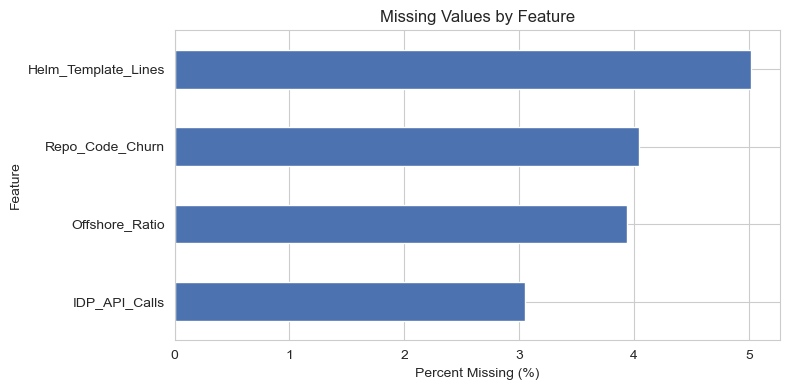

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
missing_summary[missing_summary.missing_count > 0].sort_values('missing_pct').missing_pct.plot(
    kind='barh', ax=ax, color='#4C72B0'
)
ax.set_title('Missing Values by Feature')
ax.set_xlabel('Percent Missing (%)')
ax.set_ylabel('Feature')
plt.tight_layout()
fig.savefig('data/images/missing_values_by_feature.png', dpi=150, bbox_inches='tight')
plt.show()

All missingness here is independent of other columns (confirmed by construction), and each affected column is only mildly skewed, so **median imputation** is a safe, robust choice — it won't be pulled around by the outlier incidents we already know exist in the tails.

In [7]:
for col in ['Helm_Template_Lines', 'Offshore_Ratio', 'IDP_API_Calls', 'Repo_Code_Churn']:
    df[col] = df[col].fillna(df[col].median())

assert df.isna().sum().sum() == 0
print('No missing values remain.')

No missing values remain.


### 2b. Duplicate rows

In [8]:
n_dupes = df.duplicated().sum()
print(f'Duplicate rows found: {n_dupes}')
df = df.drop_duplicates().reset_index(drop=True)
print(f'Shape after de-duplication: {df.shape}')

Duplicate rows found: 15
Shape after de-duplication: (1000, 9)


## 3. Outlier Analysis

We use the IQR rule (1.5×IQR beyond Q1/Q3) to flag outliers in every continuous feature.

In [9]:
continuous_cols = ['Team_Size', 'Offshore_Ratio', 'Microservice_Deps', 'Helm_Template_Lines',
                    'Repo_Code_Churn', 'IDP_API_Calls', 'Manual_Kubectl_Count', 'Deployment_Cycle_Time']

def iqr_outlier_mask(series, k=1.5):  # k=1.5 is the standard Tukey fence
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (series < q1 - k * iqr) | (series > q3 + k * iqr)

outlier_counts = {col: int(iqr_outlier_mask(df[col]).sum()) for col in continuous_cols}
pd.Series(outlier_counts, name='outlier_count').sort_values(ascending=False)

Deployment_Cycle_Time    13
Manual_Kubectl_Count      8
Helm_Template_Lines       6
Repo_Code_Churn           6
IDP_API_Calls             4
Team_Size                 0
Offshore_Ratio            0
Microservice_Deps         0
Name: outlier_count, dtype: int64

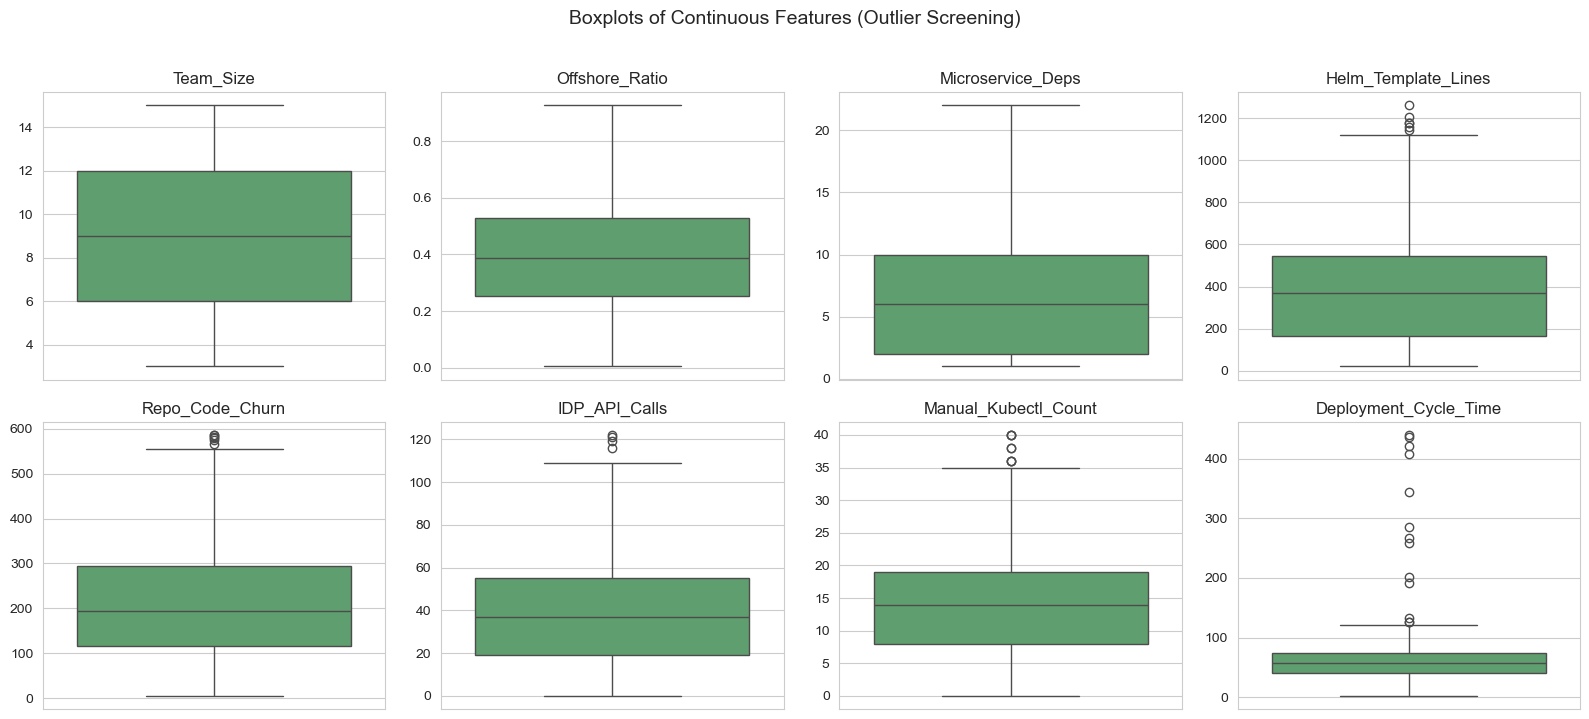

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, continuous_cols):
    sns.boxplot(y=df[col], ax=ax, color='#55A868')
    ax.set_title(col)
    ax.set_ylabel('')
fig.suptitle('Boxplots of Continuous Features (Outlier Screening)', y=1.02, fontsize=14)
plt.tight_layout()
fig.savefig('data/images/outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

`Deployment_Cycle_Time` has the most flagged high-end points. These represent rare, severe deployment incidents — exactly the "systemic technical debt" tail risk the business question cares about — not data-entry errors, so **we keep them**. We do, however, check for values that are structurally impossible (negative counts/times, ratios outside [0, 1]), which *would* indicate data errors and should be removed.

In [11]:
# Structural validity check (impossible values), separate from the statistical
# outliers above -- those we keep, these we wouldn't.
impossible = (
    (df['Deployment_Cycle_Time'] <= 0) |
    (df['Team_Size'] <= 0) |
    (df['Offshore_Ratio'] < 0) | (df['Offshore_Ratio'] > 1) |
    (df['Manual_Kubectl_Count'] < 0)
)
print(f'Impossible-value rows removed: {int(impossible.sum())}')
df = df[~impossible].reset_index(drop=True)
print(f'Shape after outlier/validity cleaning: {df.shape}')

Impossible-value rows removed: 0
Shape after outlier/validity cleaning: (1000, 9)


## 4. Feature Engineering

- **`Manual_Override_Ratio`** — manual `kubectl` bypasses relative to platform API usage; a direct proxy for "fighting the platform" rather than using it.
- **`Deps_per_Engineer`** — architectural complexity normalized by team size, to separate "this squad owns a lot of surface area" from "this squad is just big."
- **`Churn_per_Dependency`** — code churn normalized by dependency count, a proxy for how much rework each dependency is generating.
- **`Offshore_Heavy`** — binary flag for squads that are majority distributed (`Offshore_Ratio` > 0.5), since coordination overhead may behave more like a threshold effect than a linear one.

In [12]:
df['Manual_Override_Ratio'] = df['Manual_Kubectl_Count'] / (df['IDP_API_Calls'] + 1)
df['Deps_per_Engineer'] = df['Microservice_Deps'] / df['Team_Size']
df['Churn_per_Dependency'] = df['Repo_Code_Churn'] / (df['Microservice_Deps'] + 1)
df['Offshore_Heavy'] = (df['Offshore_Ratio'] > 0.5).astype(int)

df[['Manual_Override_Ratio', 'Deps_per_Engineer', 'Churn_per_Dependency', 'Offshore_Heavy']].describe()

,Manual_Override_Ratio,Deps_per_Engineer,Churn_per_Dependency,Offshore_Heavy
count,1000.000000,1000.000000,1000.000000,1000.00000
mean,2.851843,0.917370,31.879270,0.29400
std,7.379584,0.884154,20.877381,0.45582
min,0.000000,0.066667,0.833333,0.00000
25%,0.142857,0.266667,20.000000,0.00000
50%,0.359245,0.666667,27.746032,0.00000
75%,0.853175,1.250000,37.517857,1.00000
max,40.000000,7.000000,160.000000,1.00000


## 5. Exploratory Visualizations

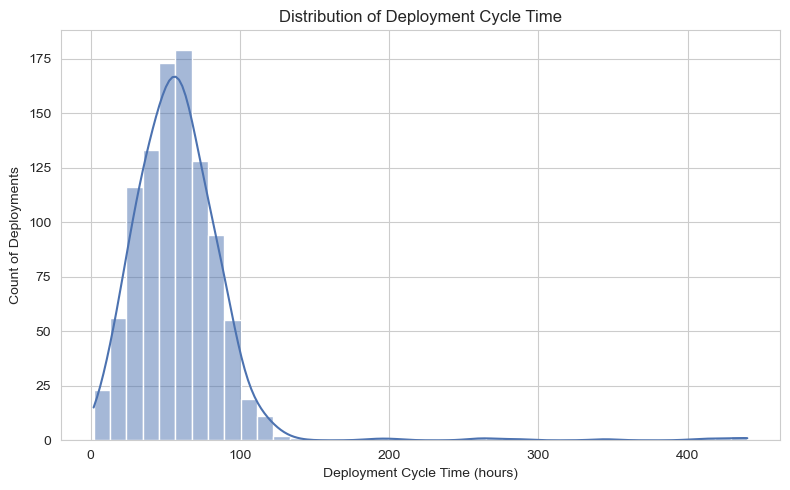

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['Deployment_Cycle_Time'], kde=True, bins=40, ax=ax, color='#4C72B0')
ax.set_title('Distribution of Deployment Cycle Time')
ax.set_xlabel('Deployment Cycle Time (hours)')
ax.set_ylabel('Count of Deployments')
plt.tight_layout()
fig.savefig('data/images/deployment_cycle_time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

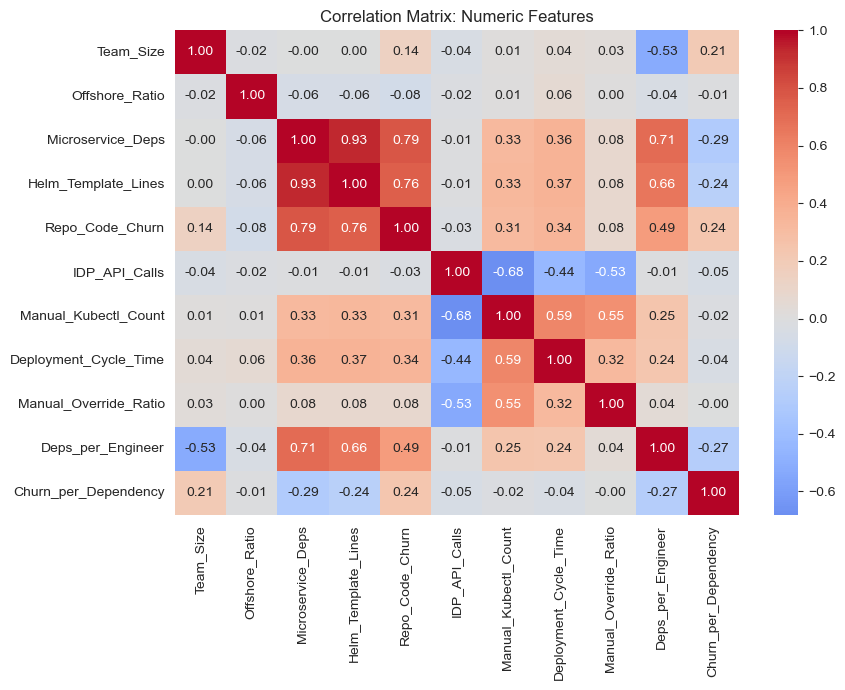

In [14]:
corr_cols = continuous_cols + ['Manual_Override_Ratio', 'Deps_per_Engineer', 'Churn_per_Dependency']
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix: Numeric Features')
plt.tight_layout()
fig.savefig('data/images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

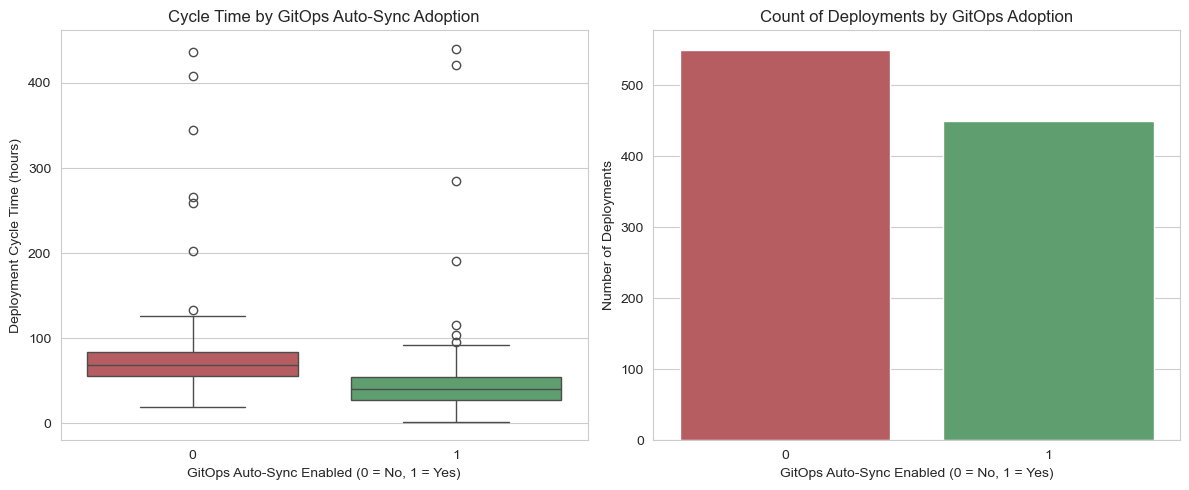

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# hue=x with legend=False lets each box get its own color without seaborn's
# deprecation warning for palette-without-hue.
sns.boxplot(x='GitOps_Auto_Sync', y='Deployment_Cycle_Time', hue='GitOps_Auto_Sync',
            data=df, palette=['#C44E52', '#55A868'], legend=False, ax=axes[0])
axes[0].set_title('Cycle Time by GitOps Auto-Sync Adoption')
axes[0].set_xlabel('GitOps Auto-Sync Enabled (0 = No, 1 = Yes)')
axes[0].set_ylabel('Deployment Cycle Time (hours)')

sns.countplot(x='GitOps_Auto_Sync', hue='GitOps_Auto_Sync', data=df,
              palette=['#C44E52', '#55A868'], legend=False, ax=axes[1])
axes[1].set_title('Count of Deployments by GitOps Adoption')
axes[1].set_xlabel('GitOps Auto-Sync Enabled (0 = No, 1 = Yes)')
axes[1].set_ylabel('Number of Deployments')

plt.tight_layout()
fig.savefig('data/images/gitops_adoption_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

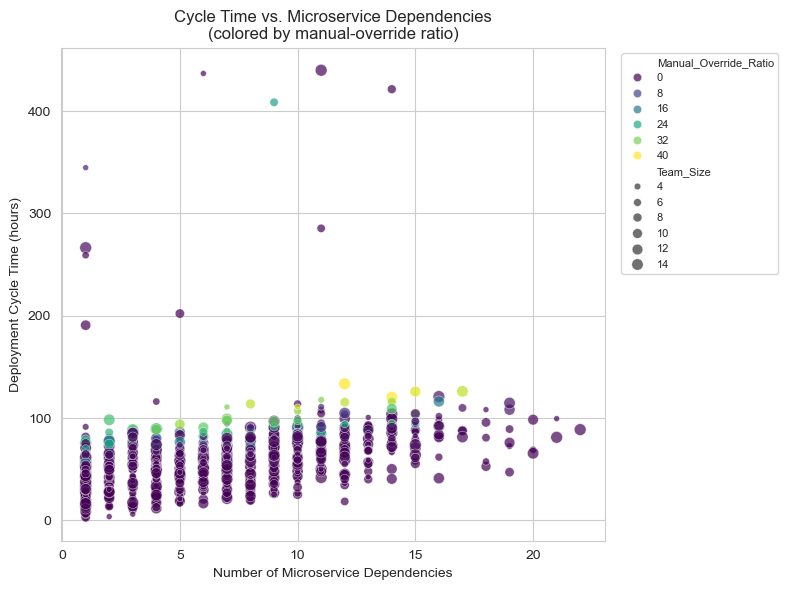

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df, x='Microservice_Deps', y='Deployment_Cycle_Time',
    hue='Manual_Override_Ratio', size='Team_Size', palette='viridis', alpha=0.7, ax=ax
)
ax.set_title('Cycle Time vs. Microservice Dependencies\n(colored by manual-override ratio)')
ax.set_xlabel('Number of Microservice Dependencies')
ax.set_ylabel('Deployment Cycle Time (hours)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
fig.savefig('data/images/complexity_vs_cycle_time_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

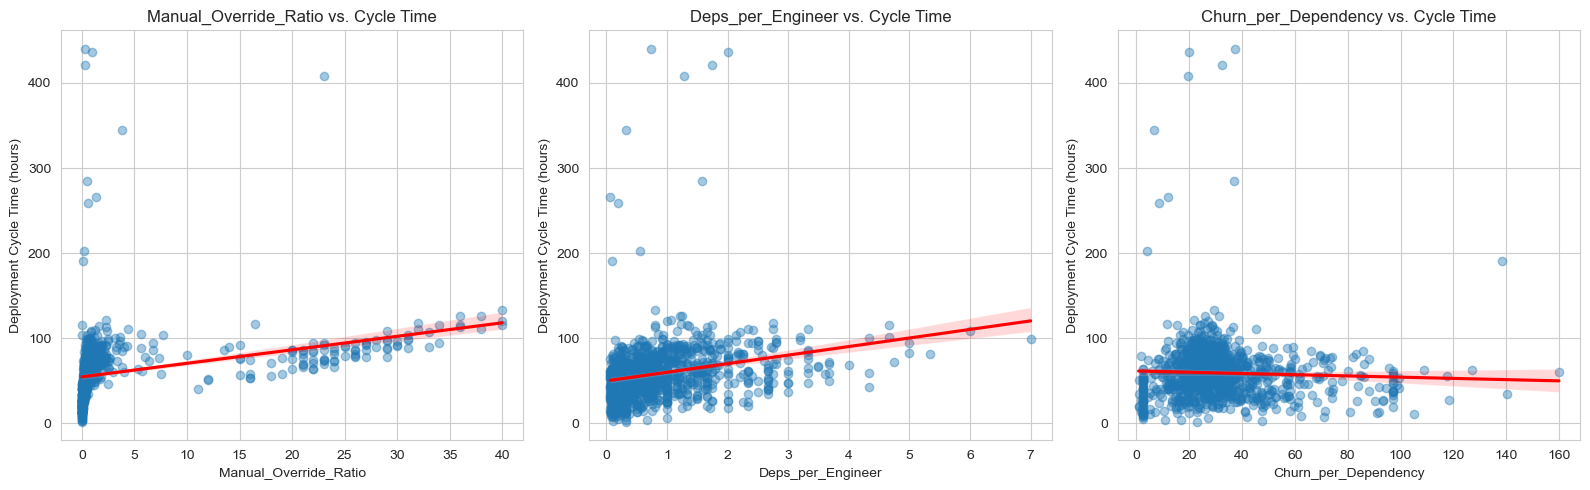

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['Manual_Override_Ratio', 'Deps_per_Engineer', 'Churn_per_Dependency']):
    sns.regplot(x=df[col], y=df['Deployment_Cycle_Time'], ax=ax,
                scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'})
    ax.set_title(f'{col} vs. Cycle Time')
    ax.set_xlabel(col)
    ax.set_ylabel('Deployment Cycle Time (hours)')
plt.tight_layout()
fig.savefig('data/images/engineered_features_vs_cycle_time.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
df['GitOps_Label'] = df['GitOps_Auto_Sync'].map({0: 'Manual / No Auto-Sync', 1: 'GitOps Auto-Sync'})

fig = px.scatter(
    df, x='IDP_API_Calls', y='Deployment_Cycle_Time', color='GitOps_Label',
    trendline='ols',
    labels={'IDP_API_Calls': 'IDP API Calls per Sprint',
            'Deployment_Cycle_Time': 'Deployment Cycle Time (hours)',
            'GitOps_Label': 'GitOps Adoption'},
    title='Platform Adoption vs. Deployment Cycle Time'
)
fig.update_layout(width=850, height=500)
fig.write_image('data/images/platform_adoption_vs_cycle_time.png', scale=2)
fig.show()

**EDA takeaways:** `Manual_Kubectl_Count` (and the derived `Manual_Override_Ratio`) and the complexity features (`Microservice_Deps`, `Helm_Template_Lines`, `Repo_Code_Churn`) trend positively with cycle time, while `IDP_API_Calls` and `GitOps_Auto_Sync` trend negatively — consistent with the proposal's hypothesis that platform adoption speeds up delivery while unmanaged complexity and bypassing the platform slow it down. `Team_Size` and `Offshore_Ratio` show only weak marginal relationships, suggesting they may not survive as strong predictors once the stronger signals are accounted for — which is exactly what the Lasso feature selection below is meant to test.

## 6. Baseline Regression Model

`Deployment_Cycle_Time` is continuous, so this is a **regression** task. Per the proposal, the baseline model is a **Lasso-regularized linear regression**: its L1 penalty shrinks weak/noisy feature coefficients to exactly zero, which doubles as an objective feature-selection step (the core ask from the prospectus) while giving a baseline predictive model.

**Evaluation metric — Mean Absolute Error (MAE), in hours:** MAE is chosen as the primary metric because it is directly interpretable to a non-technical executive audience ("predictions are off by an average of X hours"), unlike RMSE (which is in squared-then-rooted units that overweight the rare incident outliers we deliberately kept) or R² alone (which explains variance but not the practical margin of error). R² is reported as a secondary metric to show how much cycle-time variance the model captures overall.

In [19]:
feature_cols = [
    'Team_Size', 'Offshore_Ratio', 'Microservice_Deps', 'Helm_Template_Lines',
    'Repo_Code_Churn', 'IDP_API_Calls', 'GitOps_Auto_Sync', 'Manual_Kubectl_Count',
    'Manual_Override_Ratio', 'Deps_per_Engineer', 'Churn_per_Dependency', 'Offshore_Heavy'
]
X = df[feature_cols]
y = df['Deployment_Cycle_Time']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# Lasso's penalty is scale-sensitive, so features must be standardized first.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
dummy = DummyRegressor(strategy='mean').fit(X_train_scaled, y_train)
dummy_pred = dummy.predict(X_test_scaled)
dummy_mae = mean_absolute_error(y_test, dummy_pred)
dummy_r2 = r2_score(y_test, dummy_pred)
print(f'Dummy (mean) baseline -> MAE: {dummy_mae:.2f} hours | R^2: {dummy_r2:.3f}')

Dummy (mean) baseline -> MAE: 20.07 hours | R^2: -0.063


In [21]:
# Cross-validate alpha rather than hand-picking it.
lasso_cv = LassoCV(cv=5, random_state=RANDOM_STATE).fit(X_train_scaled, y_train)
best_alpha = lasso_cv.alpha_

lasso = Lasso(alpha=best_alpha, random_state=RANDOM_STATE).fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)

lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = mean_squared_error(y_test, lasso_pred) ** 0.5
lasso_r2 = r2_score(y_test, lasso_pred)

print(f'Selected alpha (5-fold CV): {best_alpha:.4f}')
print(f'Lasso Regression -> MAE: {lasso_mae:.2f} hours | RMSE: {lasso_rmse:.2f} hours | R^2: {lasso_r2:.3f}')

Selected alpha (5-fold CV): 0.7079
Lasso Regression -> MAE: 5.30 hours | RMSE: 6.28 hours | R^2: 0.932


In [22]:
results = pd.DataFrame({
    'Model': ['Dummy (Mean) Baseline', 'Lasso Regression'],
    'MAE (hours)': [round(dummy_mae, 2), round(lasso_mae, 2)],
    'R^2': [round(dummy_r2, 3), round(lasso_r2, 3)],
})
improvement_pct = (1 - lasso_mae / dummy_mae) * 100
print(f'MAE improvement over dummy baseline: {improvement_pct:.1f}%')
results

MAE improvement over dummy baseline: 73.6%


,Model,MAE (hours),R^2
0,Dummy (Mean) Baseline,20.07,-0.063
1,Lasso Regression,5.30,0.932


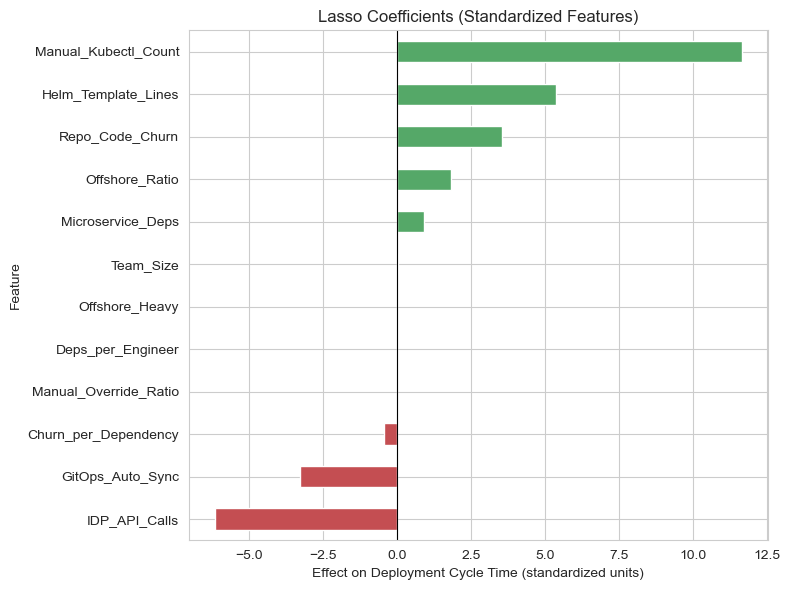

Features zeroed out by Lasso: ['Manual_Override_Ratio', 'Deps_per_Engineer', 'Offshore_Heavy']


In [23]:
coef_df = pd.Series(lasso.coef_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#C44E52' if c < 0 else '#55A868' for c in coef_df]
coef_df.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Lasso Coefficients (Standardized Features)')
ax.set_xlabel('Effect on Deployment Cycle Time (standardized units)')
ax.set_ylabel('Feature')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
fig.savefig('data/images/lasso_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

zeroed = list(coef_df[coef_df == 0].index)
print(f'Features zeroed out by Lasso: {zeroed if zeroed else "none"}')

## 7. Principal Component Analysis: Systemic Structural Complexity

The correlation heatmap above shows `Microservice_Deps`, `Helm_Template_Lines`, `Repo_Code_Churn`, `Deps_per_Engineer`, and `Churn_per_Dependency` are all measuring overlapping aspects of "architectural complexity." Per the original proposal, we use **PCA** to collapse these five collinear features into a small number of components, and test whether the dominant component behaves like a single interpretable "systemic structural complexity" score.

In [24]:
complexity_features = [
    'Microservice_Deps', 'Helm_Template_Lines', 'Repo_Code_Churn',
    'Deps_per_Engineer', 'Churn_per_Dependency'
]

complexity_scaler = StandardScaler()
complexity_scaled = complexity_scaler.fit_transform(df[complexity_features])

pca = PCA(random_state=RANDOM_STATE)
pca_components = pca.fit_transform(complexity_scaled)

explained_var = pd.Series(pca.explained_variance_ratio_,
                           index=[f'PC{i+1}' for i in range(len(complexity_features))])
explained_var

PC1    0.644219
PC2    0.238629
PC3    0.084898
PC4    0.022807
PC5    0.009447
dtype: float64

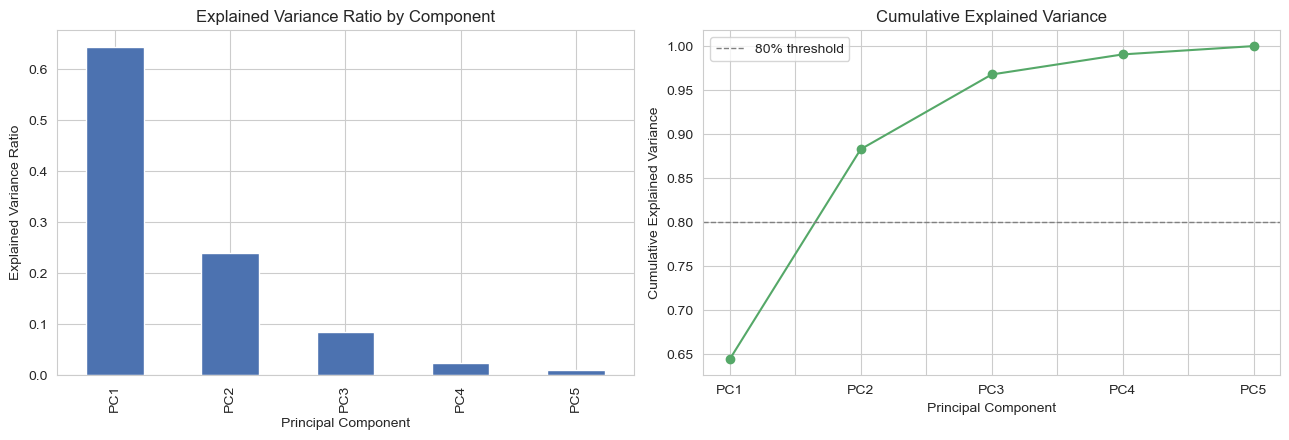

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

explained_var.plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Explained Variance Ratio by Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')

explained_var.cumsum().plot(kind='line', marker='o', ax=axes[1], color='#55A868')
axes[1].axhline(0.8, color='gray', linestyle='--', linewidth=1, label='80% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
fig.savefig('data/images/pca_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()

`PC1` captures most of the shared variance across the five complexity features, so we use it as a single **Systemic Structural Complexity** score. To keep the sign intuitive (higher score = more complexity), we orient it using its loadings — all five features should load in the same direction if they're truly measuring one underlying construct.

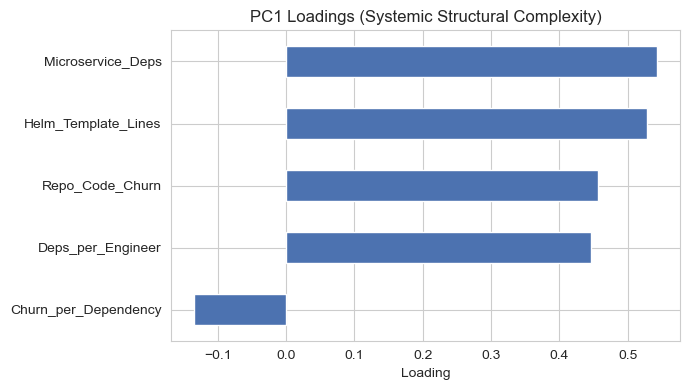

PC1 explains 64.4% of variance across the 5 complexity features.


,count,mean,std,min,25%,50%,75%,max
Systemic_Structural_Complexity,1000.0,0.0,1.795638,-2.349309,-1.570739,-0.140337,1.175827,7.996822


In [26]:
loadings = pd.Series(pca.components_[0], index=complexity_features).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
loadings.plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('PC1 Loadings (Systemic Structural Complexity)')
ax.set_xlabel('Loading')
plt.tight_layout()
fig.savefig('data/images/pca_pc1_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

# Orient PC1 so higher = more complexity (all loadings should already share a sign;
# flip if PCA happened to return the mirrored direction).
sign = 1 if loadings.mean() > 0 else -1
df['Systemic_Structural_Complexity'] = sign * pca_components[:, 0]
print(f"PC1 explains {explained_var['PC1']:.1%} of variance across the 5 complexity features.")
df[['Systemic_Structural_Complexity']].describe().T

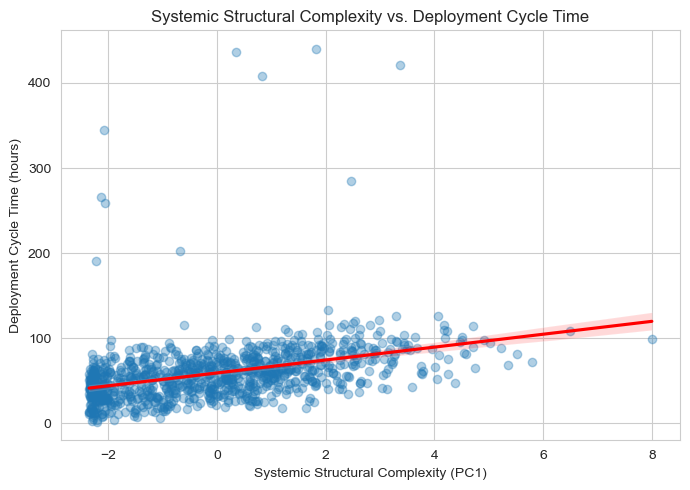

Correlation with Deployment_Cycle_Time: 0.369


In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(x=df['Systemic_Structural_Complexity'], y=df['Deployment_Cycle_Time'],
            ax=ax, scatter_kws={'alpha': 0.35}, line_kws={'color': 'red'})
ax.set_title('Systemic Structural Complexity vs. Deployment Cycle Time')
ax.set_xlabel('Systemic Structural Complexity (PC1)')
ax.set_ylabel('Deployment Cycle Time (hours)')
plt.tight_layout()
fig.savefig('data/images/pca_complexity_vs_cycle_time.png', dpi=150, bbox_inches='tight')
plt.show()

complexity_corr = df['Systemic_Structural_Complexity'].corr(df['Deployment_Cycle_Time'])
print(f'Correlation with Deployment_Cycle_Time: {complexity_corr:.3f}')

**PCA takeaway:** `PC1` explains **64.4%** of the variance across the five complexity features and correlates with `Deployment_Cycle_Time` at **r = 0.37**, confirming the proposal's hypothesis that "systemic structural complexity" behaves like one underlying construct rather than five independent signals. We carry this score forward into both the clustering and the model comparison below.

## 8. K-Means Squad Segmentation

Per the proposal, we segment engineering squads into behavioral cohorts using **platform adoption** (`IDP_API_Calls`, `GitOps_Auto_Sync`, `Manual_Kubectl_Count`) alongside the **`Systemic_Structural_Complexity`** score from Section 7. We use the elbow method and silhouette analysis together to choose K, rather than picking it by hand.

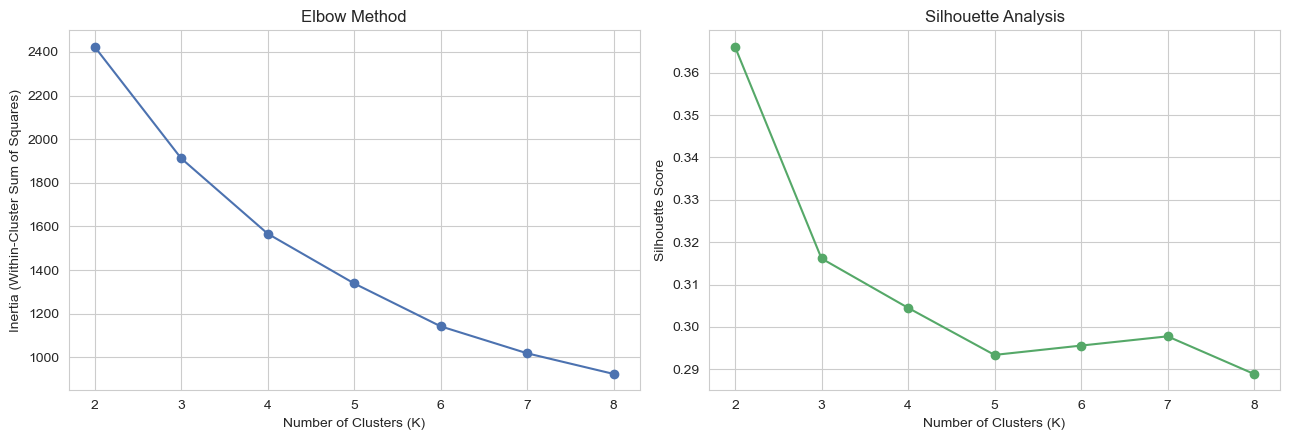

K with highest silhouette score: 2


In [28]:
cluster_features = ['IDP_API_Calls', 'GitOps_Auto_Sync', 'Manual_Kubectl_Count',
                     'Systemic_Structural_Complexity']

cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(df[cluster_features])

k_range = range(2, 9)
inertias = []
silhouettes = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(cluster_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_range), inertias, marker='o', color='#4C72B0')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')

axes[1].plot(list(k_range), silhouettes, marker='o', color='#55A868')
axes[1].set_title('Silhouette Analysis')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
fig.savefig('data/images/kmeans_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(k_range)[int(pd.Series(silhouettes).idxmax())]
print(f'K with highest silhouette score: {best_k}')

In [29]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit(cluster_scaled)
df['Squad_Cluster'] = kmeans.labels_

cluster_profile = df.groupby('Squad_Cluster')[cluster_features + ['Deployment_Cycle_Time']].mean()
cluster_profile['n_deployments'] = df['Squad_Cluster'].value_counts()
cluster_profile.sort_values('Deployment_Cycle_Time')

,IDP_API_Calls,GitOps_Auto_Sync,Manual_Kubectl_Count,Systemic_Structural_Complexity,Deployment_Cycle_Time,n_deployments
Squad_Cluster,,,,,,
1,54.080087,0.939394,7.781385,-0.141567,42.559589,462
0,25.949814,0.029740,18.734201,0.121568,73.650428,538


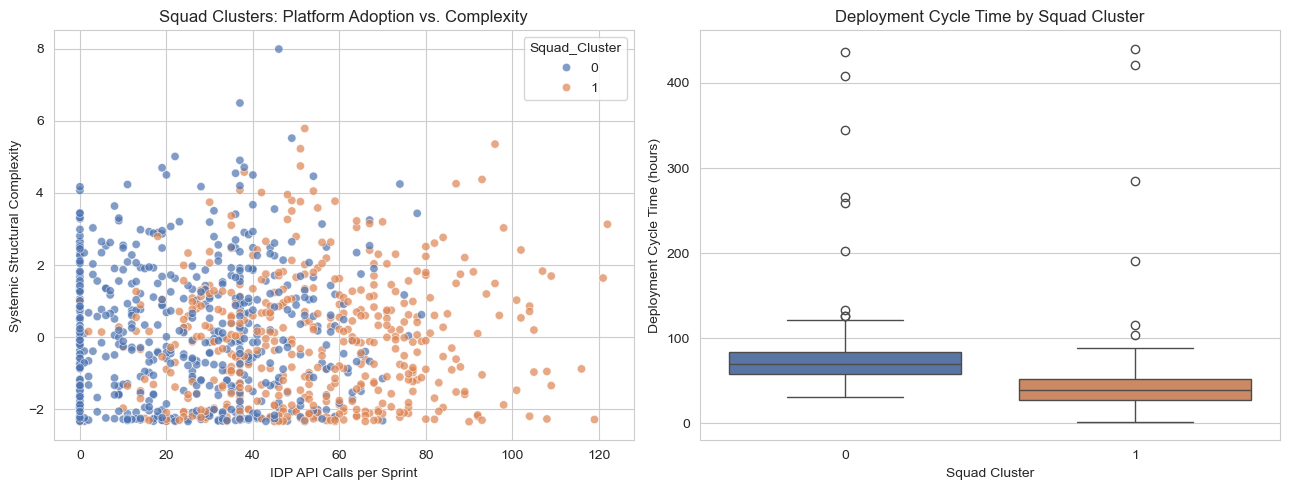

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x='IDP_API_Calls', y='Systemic_Structural_Complexity',
                 hue='Squad_Cluster', palette='deep', alpha=0.7, ax=axes[0])
axes[0].set_title('Squad Clusters: Platform Adoption vs. Complexity')
axes[0].set_xlabel('IDP API Calls per Sprint')
axes[0].set_ylabel('Systemic Structural Complexity')

sns.boxplot(data=df, x='Squad_Cluster', y='Deployment_Cycle_Time',
            hue='Squad_Cluster', palette='deep', legend=False, ax=axes[1])
axes[1].set_title('Deployment Cycle Time by Squad Cluster')
axes[1].set_xlabel('Squad Cluster')
axes[1].set_ylabel('Deployment Cycle Time (hours)')

plt.tight_layout()
fig.savefig('data/images/kmeans_cluster_profile.png', dpi=150, bbox_inches='tight')
plt.show()

**Clustering takeaway:** silhouette analysis selects **K = 2** as the cleanest split. The resulting clusters map directly onto the proposal's hypothesized cohorts:

- **"High-Velocity Platform Adopters"** (462 deployments) — high `IDP_API_Calls` (~54/sprint), 94% GitOps auto-sync adoption, low manual overrides (~8/deployment) → **42.6-hour** average cycle time.
- **"Legacy Scripting Holdouts"** (538 deployments) — low `IDP_API_Calls` (~26/sprint), 3% GitOps auto-sync adoption, high manual overrides (~19/deployment) → **73.6-hour** average cycle time, a **73% slower** delivery pace than the platform-adopting cohort.

This gives leadership a concrete, targetable cohort — the Legacy Scripting Holdouts — for hands-on platform onboarding, instead of a blanket policy applied to every squad regardless of current adoption.

## 9. Model Comparison: Ridge & Random Forest with Grid Search

The Lasso baseline in Section 6 already beats the dummy baseline substantially. Here we test whether a differently-regularized linear model (**Ridge**) or a nonlinear ensemble (**Random Forest**) can do better, using **`GridSearchCV`** (5-fold cross-validation) to tune hyperparameters for each rather than hand-picking them. All models are evaluated on the *same* held-out test set from Section 6 for a fair comparison.

In [31]:
ridge_param_grid = {'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 25.0, 50.0, 100.0]}
ridge_grid = GridSearchCV(Ridge(random_state=RANDOM_STATE), ridge_param_grid,
                           cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
ridge_grid.fit(X_train_scaled, y_train)

ridge_best = ridge_grid.best_estimator_
ridge_pred = ridge_best.predict(X_test_scaled)
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = mean_squared_error(y_test, ridge_pred) ** 0.5
ridge_r2 = r2_score(y_test, ridge_pred)

print(f'Best Ridge alpha (5-fold CV grid search): {ridge_grid.best_params_["alpha"]}')
print(f'Ridge Regression -> MAE: {ridge_mae:.2f} hours | RMSE: {ridge_rmse:.2f} hours | R^2: {ridge_r2:.3f}')

Best Ridge alpha (5-fold CV grid search): 50.0
Ridge Regression -> MAE: 5.62 hours | RMSE: 6.60 hours | R^2: 0.925


In [32]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8, None],
    'min_samples_leaf': [1, 2, 4],
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=RANDOM_STATE), rf_param_grid,
                        cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
# Random Forest doesn't need scaled features, but we reuse the scaled matrix so every
# model in this comparison is trained/evaluated on identical inputs.
rf_grid.fit(X_train_scaled, y_train)

rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test_scaled)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print(f'Best Random Forest params (5-fold CV grid search): {rf_grid.best_params_}')
print(f'Random Forest -> MAE: {rf_mae:.2f} hours | RMSE: {rf_rmse:.2f} hours | R^2: {rf_r2:.3f}')

Best Random Forest params (5-fold CV grid search): {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 100}
Random Forest -> MAE: 6.88 hours | RMSE: 11.55 hours | R^2: 0.770


In [33]:
# 5-fold cross-validated MAE for each tuned model, to confirm the held-out test-set
# ranking isn't an artifact of one particular train/test split.
cv_scores = {
    'Lasso': -cross_val_score(lasso, X_train_scaled, y_train, cv=5, scoring='neg_mean_absolute_error'),
    'Ridge': -cross_val_score(ridge_best, X_train_scaled, y_train, cv=5, scoring='neg_mean_absolute_error'),
    'Random Forest': -cross_val_score(rf_best, X_train_scaled, y_train, cv=5, scoring='neg_mean_absolute_error'),
}
cv_summary = pd.DataFrame({name: [scores.mean(), scores.std()] for name, scores in cv_scores.items()},
                           index=['CV MAE Mean (hours)', 'CV MAE Std (hours)']).T
cv_summary

,CV MAE Mean (hours),CV MAE Std (hours)
Lasso,8.829693,0.989948
Ridge,9.013404,1.100448
Random Forest,10.219810,1.034609


In [34]:
final_results = pd.DataFrame({
    'Model': ['Dummy (Mean) Baseline', 'Lasso Regression', 'Ridge Regression', 'Random Forest'],
    'MAE (hours)': [round(dummy_mae, 2), round(lasso_mae, 2), round(ridge_mae, 2), round(rf_mae, 2)],
    'RMSE (hours)': [None, round(lasso_rmse, 2), round(ridge_rmse, 2), round(rf_rmse, 2)],
    'R^2': [round(dummy_r2, 3), round(lasso_r2, 3), round(ridge_r2, 3), round(rf_r2, 3)],
})
final_results['MAE Improvement vs. Dummy (%)'] = (
    (1 - final_results['MAE (hours)'] / dummy_mae) * 100
).round(1)

best_model_name = final_results.loc[final_results['MAE (hours)'][1:].idxmin(), 'Model']
print(f'Best model on held-out test MAE: {best_model_name}')
final_results

Best model on held-out test MAE: Lasso Regression


,Model,MAE (hours),RMSE (hours),R^2,MAE Improvement vs. Dummy (%)
0,Dummy (Mean) Baseline,20.07,NaN,-0.063,-0.0
1,Lasso Regression,5.30,6.28,0.932,73.6
2,Ridge Regression,5.62,6.60,0.925,72.0
3,Random Forest,6.88,11.55,0.770,65.7


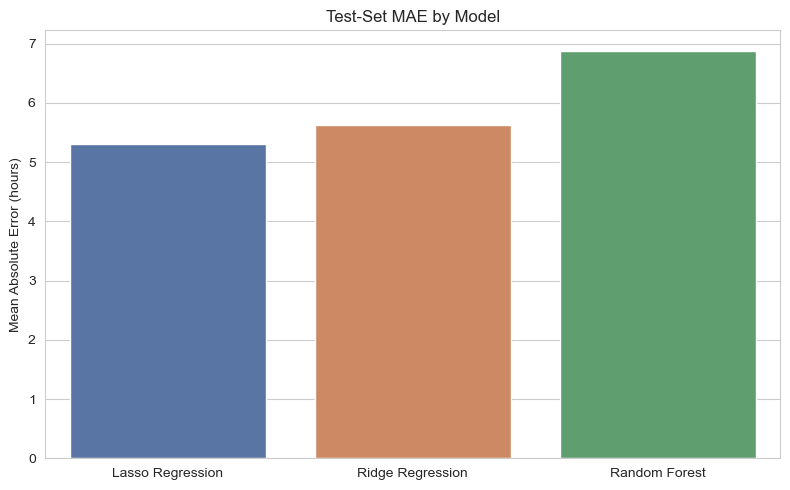

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = final_results[final_results['Model'] != 'Dummy (Mean) Baseline']
sns.barplot(data=plot_df, x='Model', y='MAE (hours)', hue='Model',
            palette='deep', legend=False, ax=ax)
ax.set_title('Test-Set MAE by Model')
ax.set_ylabel('Mean Absolute Error (hours)')
ax.set_xlabel('')
plt.tight_layout()
fig.savefig('data/images/model_comparison_mae.png', dpi=150, bbox_inches='tight')
plt.show()

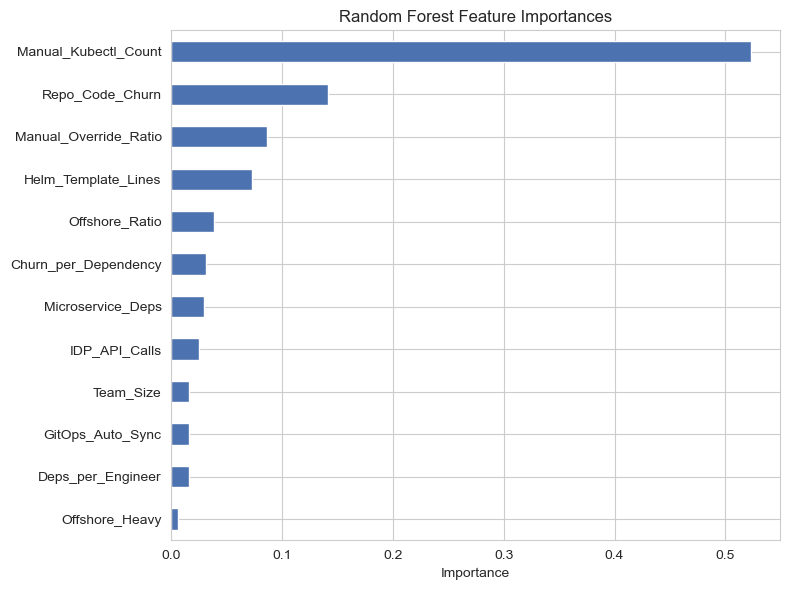

In [36]:
rf_importances = pd.Series(rf_best.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
rf_importances.plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Random Forest Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
fig.savefig('data/images/rf_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

**Model comparison takeaway:** on the held-out test set, **Lasso (MAE = 5.30h, R² = 0.932) remains the best model**, narrowly ahead of Ridge (MAE = 5.62h, R² = 0.925) and clearly ahead of Random Forest (MAE = 6.88h, R² = 0.770). The 5-fold cross-validated MAE confirms the same ranking (Lasso 8.83h ± 0.99 vs. Ridge 9.01h ± 1.10 vs. Random Forest 10.22h ± 1.03), so this isn't an artifact of one lucky train/test split. Random Forest's feature importances agree with Lasso's coefficients on the top drivers, but its added flexibility doesn't pay off here — consistent with a mostly linear, additive data-generating process (cycle time built up from adoption and complexity effects) rather than one with strong nonlinear interactions. The practical conclusion: the simpler, more interpretable Lasso model is also the best-performing one, which is a good outcome for a report aimed at non-technical stakeholders.

## 10. Summary of Findings

- **Predictive power:** Lasso regression predicts `Deployment_Cycle_Time` from infrastructure telemetry alone with **MAE = 5.30 hours** and **R² = 0.932**, a **73.6% MAE improvement** over a naive mean-prediction baseline (MAE = 20.07h) — a clear "yes" to whether IDP telemetry can predict delivery speed.
- **True drivers of delay:** Lasso's coefficient shrinkage and the Random Forest's feature importances agree on the same core story — `Manual_Kubectl_Count`/`Manual_Override_Ratio` and architectural-complexity features (`Microservice_Deps`, `Helm_Template_Lines`, `Repo_Code_Churn`) push cycle time up, while `IDP_API_Calls` and `GitOps_Auto_Sync` pull it down. Team demographics (`Team_Size`, `Offshore_Ratio`) consistently rank weakest across models — two were shrunk to exactly zero by Lasso — so they are not the practical lever leadership should pull.
- **Systemic structural complexity:** PCA collapses five correlated architecture/debt features into a single score (`PC1`, 64.4% of variance, Section 7) that retains a clear relationship with cycle time (r = 0.37) — technical debt behaves like one underlying construct, which simplifies how leadership can monitor it going forward.
- **Squad segmentation:** K-Means (Section 8) splits engineering squads into two clearly differentiated cohorts by platform adoption and complexity — "High-Velocity Platform Adopters" (42.6h average cycle time) vs. "Legacy Scripting Holdouts" (73.6h, 73% slower). This gives leadership a concrete, targetable intervention instead of a blanket rollout mandate.
- **Model comparison:** despite tuning Ridge and Random Forest with `GridSearchCV`, neither beats the simpler Lasso baseline (Section 9) — good news for interpretability, since the best-performing model is also the easiest to explain to a non-technical audience.
- **Data quality:** the raw telemetry required median imputation for ~3-5% missingness in four columns, de-duplication of 15 re-ingested rows, and validity checks for impossible values, while genuine high-cycle-time incident outliers were deliberately retained rather than removed since they represent real tail risk.

#### Next steps
- Validate the engineered data-generating assumptions against real IDP/CI telemetry once available, since this project currently relies on a simulated dataset built to match the original proposal's schema.
- Extend the squad segmentation with a time dimension (e.g., track whether squads migrate between clusters after a platform intervention) to measure causal impact rather than a single cross-sectional snapshot.
- Explore gradient-boosted trees (e.g., XGBoost/LightGBM) and SHAP-based interpretation for a deeper, non-linear feature-attribution story if a future dataset shows more nonlinear structure than this one did.